In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from torch.utils.data import Dataset, DataLoader
from skimage import io, transform
import os
import random

transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
])

class FaceLandmarksDataset(Dataset):
    """Face Landmarks dataset."""

    def __init__(self, csv_file, img_root_dir, transform=None, augment=False):
        self.landmarks_frame = []
        file = open(csv_file, "r")
        while True:
            content=file.readline()
            if not content:
                break
            self.landmarks_frame.append(content.split())
        file.close()
        self.landmarks_frame = self.landmarks_frame[2:]

        self.img_root_dir = img_root_dir
        self.transform = transform
        self.augment = augment

    def __len__(self):
        return len(self.landmarks_frame)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        img_name = os.path.join(self.img_root_dir, self.landmarks_frame[idx][0])
        image = io.imread(img_name)
        landmarks = self.landmarks_frame[idx][1:]
        landmarks = np.array([landmarks], dtype=float).reshape(-1, 2)
        # landmarks order: left_eye, right_eye, nose, left_mouth, right_mouth

        # Horizontal flip augmentation
        if self.augment and random.random() > 0.5:
            image = np.fliplr(image).copy()
            img_w = image.shape[1]  # 178
            landmarks[:, 0] = img_w - landmarks[:, 0]
            # Swap: left_eye(0) <-> right_eye(1), left_mouth(3) <-> right_mouth(4)
            landmarks[[0, 1]] = landmarks[[1, 0]]
            landmarks[[3, 4]] = landmarks[[4, 3]]

        scaled_landmarks = landmarks.copy()
        scaled_landmarks[:, 0], scaled_landmarks[:, 1] = scaled_landmarks[:, 0] / 178, scaled_landmarks[:, 1] / 218
        if self.transform:
            image_tr = self.transform(image)
        scaled_landmarks = scaled_landmarks.reshape(-1)
        sample = {'image': image, 'image_tr':image_tr, 'landmarks': landmarks, 'scaled_landmarks': scaled_landmarks}

        return sample


In [28]:
# from torchvision import datasets
# from torchvision import transforms
# full_dataset = datasets.CelebA(root='./',split="train", target_type="landmarks" ,download=True, transform=torchvision.transforms.Compose([transforms.PILToTensor()]))

In [29]:
import os

path = r"C:\Users\my tech\Documents\1. 3A\DL\data\img_align_celeba"
print(os.path.exists(path))
print(len(os.listdir(path)))
print(os.listdir(path)[:5])
landmarks_file = r"C:\Users\my tech\Documents\1. 3A\DL\data\list_landmarks_align_celeba.txt"
print(os.path.exists(landmarks_file))
with open(landmarks_file, "r") as f:
    lines = f.readlines()
    print(lines[:5])

True
202599
['000001.jpg', '000002.jpg', '000003.jpg', '000004.jpg', '000005.jpg']
True
['202599\n', 'lefteye_x lefteye_y righteye_x righteye_y nose_x nose_y leftmouth_x leftmouth_y rightmouth_x rightmouth_y\n', '000001.jpg 69  109  106  113   77  142   73  152  108  154\n', '000002.jpg 69  110  107  112   81  135   70  151  108  153\n', '000003.jpg 76  112  104  106  108  128   74  156   98  158\n']


In [ ]:
full_dataset = FaceLandmarksDataset(landmarks_file, path, transform=transform, augment=True)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_set, test_set = torch.utils.data.random_split(full_dataset, [train_size, test_size])

print(train_set.__len__(), test_set.__len__())

162079 40520


In [31]:
# print(train_set[0].shape, test_set[0].shape)

In [32]:
sample = train_set[1000]
landmarks = sample['landmarks']
image = sample['image']
print(sample['image_tr'][0,:5,0:5])
print(sample['scaled_landmarks'].shape)
def show_landmarks(image, landmarks):
    """Show image with landmarks"""
    plt.imshow(image)
    plt.scatter(landmarks[:, 0], landmarks[:, 1], s=5, marker='.', c='r')
    plt.pause(0.001)  # pause a bit so that plots are updated

print(train_set[0])


tensor([[0.7098, 0.7176, 0.7216, 0.7098, 0.6980],
        [0.7098, 0.7176, 0.7216, 0.7098, 0.6980],
        [0.7098, 0.7176, 0.7216, 0.7137, 0.6980],
        [0.7059, 0.7176, 0.7216, 0.7137, 0.7020],
        [0.7020, 0.7137, 0.7216, 0.7176, 0.7059]])
(10,)
{'image': array([[[ 33,  34,  39],
        [ 33,  34,  39],
        [ 30,  33,  38],
        ...,
        [ 40,  51,  55],
        [ 32,  39,  47],
        [ 26,  33,  41]],

       [[ 32,  33,  38],
        [ 33,  34,  39],
        [ 31,  34,  39],
        ...,
        [ 50,  61,  65],
        [ 38,  45,  53],
        [ 32,  39,  47]],

       [[ 30,  33,  38],
        [ 31,  34,  39],
        [ 32,  35,  40],
        ...,
        [ 64,  75,  79],
        [ 48,  55,  63],
        [ 43,  50,  58]],

       ...,

       [[150, 132, 122],
        [149, 131, 121],
        [148, 130, 120],
        ...,
        [ 24,  23,  29],
        [ 19,  20,  24],
        [ 19,  20,  24]],

       [[144, 126, 116],
        [144, 126, 116],
        [1

In [33]:
dataloader = DataLoader(train_set, batch_size=4,
                        shuffle=True, num_workers=0)

In [34]:
for i in dataloader:
    print(i['image_tr'].shape)
    landmarks = i['scaled_landmarks']
    image = i['image_tr']
    print(image.shape, landmarks.shape)
    break

torch.Size([4, 3, 218, 178])
torch.Size([4, 3, 218, 178]) torch.Size([4, 10])


# Model

In [35]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_chanels, **kwargs):
        super(ConvBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_chanels, **kwargs)
        self.bn = nn.BatchNorm2d(out_chanels)

    def forward(self, x):
        return F.relu(self.bn(self.conv(x)))

class InceptionBlock(nn.Module):
    def __init__(self,  in_channels,  out_1x1, red_3x3, out_3x3, red_5x5, out_5x5, out_pool):

        super(InceptionBlock, self).__init__()
        self.branch1 = ConvBlock(in_channels, out_1x1, kernel_size=1)
        self.branch2 = nn.Sequential(
            ConvBlock(in_channels, red_3x3, kernel_size=1, padding=0),
            ConvBlock(red_3x3, out_3x3, kernel_size=3, padding=1))
        self.branch3 = nn.Sequential(
            ConvBlock(in_channels, red_5x5, kernel_size=1),
            ConvBlock(red_5x5, out_5x5, kernel_size=5, padding=2))
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, padding=1, stride=1),
            ConvBlock(in_channels, out_pool, kernel_size=1))

    def forward(self, x):
        branches = (self.branch1, self.branch2, self.branch3, self.branch4)
        return torch.cat([branch(x) for branch in branches], 1)

In [36]:
class InceptionModel(nn.Module):
    def __init__(self, aux = False, residual = True, num_classes = 1000):
        super(InceptionModel, self).__init__()
        self.aux = aux
        self.residual  = residual
        self.dropout = nn.Dropout(p=0.4)
        self.fc = nn.Linear(512, num_classes)

        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.avgpool = nn.AvgPool2d(kernel_size=(7,6), stride=1)

        self.conv1 = ConvBlock(in_channels=3, out_chanels=64, kernel_size=(7,7), stride=(2,2), padding=(3,3))
        self.conv2 = ConvBlock(in_channels=64, out_chanels=192, kernel_size=3, stride=1, padding=1)

        self.incept3a = InceptionBlock(in_channels=192, out_1x1=64, red_3x3=96, out_3x3=128, red_5x5=16, out_5x5=32, out_pool=32)
        self.incept3b = InceptionBlock(in_channels=256, out_1x1=128, red_3x3=128, out_3x3=192, red_5x5=32, out_5x5=112, out_pool=80)

        self.incept4a = InceptionBlock(in_channels=512, out_1x1=192, red_3x3=96, out_3x3=208, red_5x5=16, out_5x5=48, out_pool=64)
        self.incept4b = InceptionBlock(in_channels=512, out_1x1=160, red_3x3=112, out_3x3=224, red_5x5=24, out_5x5=64, out_pool=64)

        self.incept5a = InceptionBlock(in_channels=512, out_1x1=256, red_3x3=160, out_3x3=320, red_5x5=32, out_5x5=128, out_pool=128)
        self.incept5b = InceptionBlock(in_channels=832, out_1x1=128, red_3x3=112, out_3x3=256, red_5x5=32, out_5x5=64, out_pool=64)

    def forward(self, x):
        x = self.conv1(x)
        x = self.maxpool(x)
        x = self.conv2(x)
        x = self.maxpool(x)
        x = self.incept3a(x)
        x = self.incept3b(x)
        residual = self.maxpool(x)

        x = self.incept4a(residual)
        x = self.incept4b(x)
        x += residual
        residual = self.maxpool(x)

        x = self.incept5a(residual)
        x = self.incept5b(x)
        x += residual
        x = self.avgpool(x)
        x = x.reshape(x.shape[0], -1)
        x = self.dropout(x)
        x = F.relu(self.fc(x))

        return x

In [37]:
dummy_input = torch.rand(8,3,218,178)
print(dummy_input.shape)

torch.Size([8, 3, 218, 178])


In [38]:
net = InceptionModel(num_classes=10)
out = net(dummy_input)

print(out.shape)

torch.Size([8, 10])


In [39]:
net

InceptionModel(
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=512, out_features=10, bias=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (avgpool): AvgPool2d(kernel_size=(7, 6), stride=1, padding=0)
  (conv1): ConvBlock(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv2): ConvBlock(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (incept3a): InceptionBlock(
    (branch1): ConvBlock(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1))
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (branch2): Sequential(
      (0): ConvBlock(
        (conv): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1))
     

In [40]:
from torchvision import models
class Network(nn.Module):
    def __init__(self,num_classes=10):
        super().__init__()
        self.model=models.resnet18()
        self.model.conv1=nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.model.fc=nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        x=self.model(x)
        return x

# Training

In [41]:
def inference(model, device):
    model.eval()
    with torch.no_grad():
        data = test_set[-1]
        image, target = torch.tensor(data["image_tr"], dtype=torch.float32).unsqueeze(0).to(device),  torch.tensor(data["scaled_landmarks"],dtype=torch.float32).unsqueeze(0).to(device)
        print(image.shape)
        output = model(image)
        landmarks = np.array([output.cpu().detach()], dtype=float).reshape(-1, 2)
        landmarks[:, 0], landmarks[:, 1] = landmarks[:, 0] * 178, landmarks[:, 1] * 218
        landmarks = np.int8(landmarks)
        loss = F.mse_loss(output, target, reduction='sum').item()
        print('loss: ', loss, 'out: ', landmarks)
        # plt.figure()
        # show_landmarks(data["image"], data["landmarks"])
        # plt.show()

        # plt.figure()
        # show_landmarks(data["image"], landmarks)
        # plt.show()

def train(model, device, train_loader, optimizer, epoch):
    model.train()
    for batch_idx, data in enumerate(train_loader):
        image, target = data["image_tr"].to(device).float(), data["scaled_landmarks"].to(device).float()
        optimizer.zero_grad()
        output = model(image)
        loss = F.mse_loss(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(image), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))


def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data in test_loader:
            image, target = data["image_tr"].to(device).float(), data["scaled_landmarks"].to(device).float()
            output = model(image)
            test_loss += F.mse_loss(output, target, reduction='sum').item()  # sum up batch loss
    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}\n'.format(test_loss))


def main():
    epochs = 1
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print('Using device:', device)
    train_loader = DataLoader(train_set, batch_size=64,
                        shuffle=True, num_workers=0)
    test_loader = DataLoader(test_set, batch_size=64,
                        shuffle=True, num_workers=0)
    # model = InceptionModel(num_classes=10)
    model = Network(10)
    model.to(device)
    optimizer = torch.optim.Adadelta(model.parameters(), lr=0.001)
    scheduler = StepLR(optimizer, step_size=1, gamma=0.7)
    for epoch in range(1, epochs + 1):
        train(model, device, train_loader, optimizer, epoch)
        test(model, device, test_loader)
        scheduler.step()
    torch.save(model.state_dict(), "./own_res_incept5.pt")
    inference(model, device)

In [42]:
from torch.optim.lr_scheduler import StepLR
main()

Using device: cuda
Train Epoch: 1 [0/162079 (0%)]	Loss: 0.265936


KeyboardInterrupt: 

In [43]:
import time
network = Network(10)
network.cuda()

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
train_loader = DataLoader(train_set, batch_size=64,
                    shuffle=True, num_workers=0)
valid_loader = DataLoader(test_set, batch_size=64,
                    shuffle=True, num_workers=0)
loss_min = np.inf
num_epochs = 30

start_time = time.time()
for epoch in range(1, num_epochs+1):

    loss_train = 0
    loss_valid = 0

    # Training - scaled_landmarks ашиглах, iterator-ийг зөв ашиглах
    network.train()
    for data in train_loader:
        images = data["image_tr"].float().cuda()
        landmarks = data["scaled_landmarks"].float().cuda()

        predictions = network(images)
        optimizer.zero_grad()
        loss_train_step = criterion(predictions, landmarks)
        loss_train_step.backward()
        optimizer.step()

        loss_train += loss_train_step.item()

    # Validation - valid_loader ашиглах (train_loader биш)
    network.eval()
    with torch.no_grad():
        for data in valid_loader:
            images = data["image_tr"].float().cuda()
            landmarks = data["scaled_landmarks"].float().cuda()

            predictions = network(images)
            loss_valid_step = criterion(predictions, landmarks)
            loss_valid += loss_valid_step.item()

    loss_train /= len(train_loader)
    loss_valid /= len(valid_loader)
    scheduler.step(loss_valid)

    print(f'\nEpoch: {epoch}  Train Loss: {loss_train:.4f}  Valid Loss: {loss_valid:.4f}  LR: {optimizer.param_groups[0]["lr"]:.6f}')

    if loss_valid < loss_min:
        loss_min = loss_valid
        torch.save(network.state_dict(), './face_landmarks.pth')
        print(f"  -> New best! Saved (Valid Loss: {loss_min:.4f})")

print(f'\nTraining Complete - Total Time: {time.time()-start_time:.1f}s')


Epoch: 1  Train Loss: 0.0023  Valid Loss: 0.0002  LR: 0.001000
  -> New best! Saved (Valid Loss: 0.0002)

Epoch: 2  Train Loss: 0.0002  Valid Loss: 0.0002  LR: 0.001000
  -> New best! Saved (Valid Loss: 0.0002)


KeyboardInterrupt: 

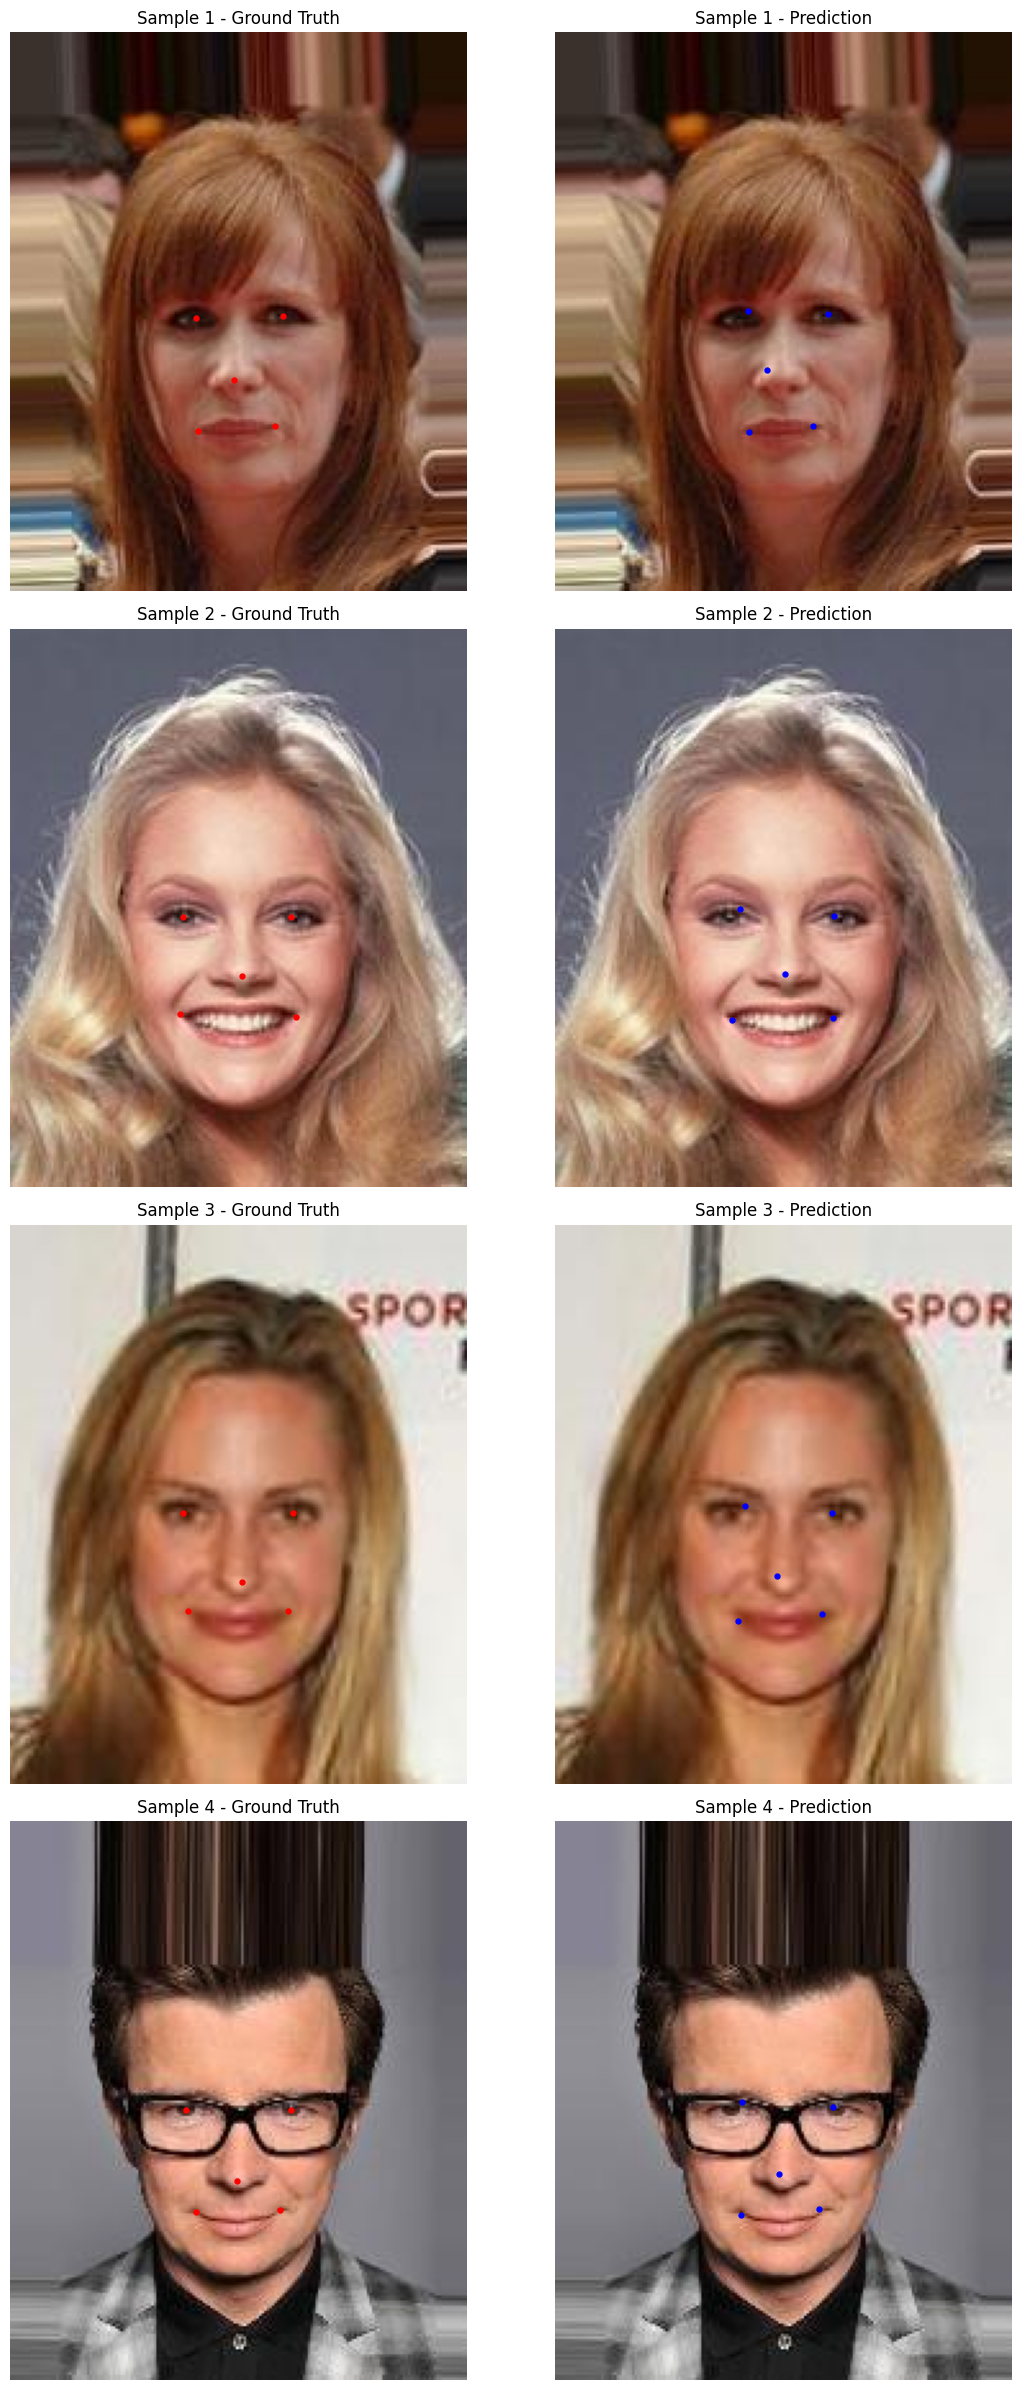

In [44]:
# Хадгалсан модел ачаалах
best_network = Network(10)
best_network.load_state_dict(torch.load('./face_landmarks.pth'))
best_network.cuda()
best_network.eval()
            
# Олон зургийн таамаглал харуулах
num_samples = 4
fig, axes = plt.subplots(num_samples, 2, figsize=(12, 6 * num_samples))

with torch.no_grad():
    for i in range(num_samples):
        sample = test_set[i * 100]
        image = sample['image']
        image_tr = sample['image_tr'].unsqueeze(0).float().cuda()
        gt_landmarks = sample['landmarks']

        # Prediction -> scaled coords буцааж pixel coords руу хөрвүүлэх
        pred_scaled = best_network(image_tr).cpu().numpy().reshape(-1, 2)
        prediction = pred_scaled.copy()
        prediction[:, 0] = pred_scaled[:, 0] * 178
        prediction[:, 1] = pred_scaled[:, 1] * 218

        # Ground truth
        axes[i, 0].imshow(image)
        axes[i, 0].scatter(gt_landmarks[:, 0], gt_landmarks[:, 1], s=50, marker='.', c='r')
        axes[i, 0].set_title(f'Sample {i+1} - Ground Truth')
        axes[i, 0].axis('off')

        # Prediction
        axes[i, 1].imshow(image)
        axes[i, 1].scatter(prediction[:, 0], prediction[:, 1], s=50, marker='.', c='b')
        axes[i, 1].set_title(f'Sample {i+1} - Prediction')
        axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [45]:
# Моделийн хэмжээ
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    size_mb = total * 4 / (1024 ** 2)  # float32 = 4 bytes
    print(f"Нийт параметр: {total:,}")
    print(f"Сургагдах параметр: {trainable:,}")
    print(f"Моделийн хэмжээ: {size_mb:.2f} MB")

print("=== Network (ResNet18) ===")
count_parameters(best_network)
print()
print("=== InceptionModel ===")
count_parameters(net)

=== Network (ResNet18) ===
Нийт параметр: 11,181,642
Сургагдах параметр: 11,181,642
Моделийн хэмжээ: 42.65 MB

=== InceptionModel ===
Нийт параметр: 2,988,946
Сургагдах параметр: 2,988,946
Моделийн хэмжээ: 11.40 MB
